In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ---------- PART 1: Fetch data from OpenFoodFacts API ----------
import requests
import pandas as pd
from IPython.display import display

all_products = []
page = 1
page_size = 100
target_records = 12000

while len(all_products) < target_records:
    url = f"https://world.openfoodfacts.org/api/v2/search?categories=chocolates&fields=code,product_name,brands,nutriments&page_size={page_size}&page={page}"
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()

        if not data.get('products'):
            print(f"No products found on page {page}. Stopping.")
            break

        all_products.extend(data['products'])
        print(f"Collected {len(all_products)} records so far.")
        page += 1

    except requests.exceptions.RequestException as e:
        print(f"Error fetching page {page}: {e}")
        break

print(f"Finished collecting {len(all_products)} records.")

# Convert into DataFrame
df_raw = pd.DataFrame(all_products)

# Display raw data
display(df_raw)


Collected 100 records so far.
Collected 200 records so far.
Collected 300 records so far.
Collected 400 records so far.
Collected 500 records so far.
Collected 600 records so far.
Collected 700 records so far.
Collected 800 records so far.
Collected 900 records so far.
Collected 1000 records so far.
Collected 1100 records so far.
Collected 1200 records so far.
Collected 1300 records so far.
Collected 1400 records so far.
Collected 1499 records so far.
Collected 1599 records so far.
Collected 1699 records so far.
Collected 1799 records so far.
Collected 1899 records so far.
Collected 1999 records so far.
Collected 2099 records so far.
Collected 2199 records so far.
Collected 2299 records so far.
Collected 2399 records so far.
Collected 2499 records so far.
Collected 2599 records so far.
Collected 2699 records so far.
Collected 2799 records so far.
Collected 2899 records so far.
Collected 2999 records so far.
Collected 3099 records so far.
Collected 3199 records so far.
Collected 3299 re

,brands,code,nutriments,product_name
0,Sidi Ali,6111035000430,"{'carbohydrates': 42, 'carbohydrates_100g': 4....",Sidi Ali
1,Jaouda,6111242100992,"{'calcium': 0.25, 'calcium_100g': 0.25, 'calci...",Perly
2,sidi ali,6111035002175,"{'chloride': 0.014, 'chloride_100g': 0.014, 'c...",Sidi Ali
3,"Les Eaux Minérales d'oulmès,Sidi Ali",6111035000058,{'fruits-vegetables-legumes-estimate-from-ingr...,Eau minérale naturelle
4,AQUAFINA,6111252421568,"{'alcohol': 0, 'alcohol_100g': 0, 'alcohol_ser...",اكوافينا
...,...,...,...,...
12092,Bjorg,3229820789910,"{'carbohydrates': 5.7, 'carbohydrates_100g': 5...",Amande Noisette
12093,"Paquito, Sélection Intermarché",3250390769811,"{'alcohol': 0, 'alcohol_100g': 0, 'alcohol_ser...",100% pur jus orange sans pulpe
12094,Carrefour,3560070581870,"{'carbohydrates': 57, 'carbohydrates_100g': 57...",Crunchy
12095,"Marque Repère, Épi d'Or",3564700562802,"{'carbohydrates': 51, 'carbohydrates_100g': 51...",Brioche tranchée


In [3]:
import pandas as pd

df = pd.DataFrame(all_products)
df

,brands,code,nutriments,product_name
0,Sidi Ali,6111035000430,"{'carbohydrates': 42, 'carbohydrates_100g': 4....",Sidi Ali
1,Jaouda,6111242100992,"{'calcium': 0.25, 'calcium_100g': 0.25, 'calci...",Perly
2,sidi ali,6111035002175,"{'chloride': 0.014, 'chloride_100g': 0.014, 'c...",Sidi Ali
3,"Les Eaux Minérales d'oulmès,Sidi Ali",6111035000058,{'fruits-vegetables-legumes-estimate-from-ingr...,Eau minérale naturelle
4,AQUAFINA,6111252421568,"{'alcohol': 0, 'alcohol_100g': 0, 'alcohol_ser...",اكوافينا
...,...,...,...,...
12092,Bjorg,3229820789910,"{'carbohydrates': 5.7, 'carbohydrates_100g': 5...",Amande Noisette
12093,"Paquito, Sélection Intermarché",3250390769811,"{'alcohol': 0, 'alcohol_100g': 0, 'alcohol_ser...",100% pur jus orange sans pulpe
12094,Carrefour,3560070581870,"{'carbohydrates': 57, 'carbohydrates_100g': 57...",Crunchy
12095,"Marque Repère, Épi d'Or",3564700562802,"{'carbohydrates': 51, 'carbohydrates_100g': 51...",Brioche tranchée


In [5]:
nutriments_df = pd.DataFrame(df['nutriments'].tolist())
display(nutriments_df)

,carbohydrates,carbohydrates_100g,carbohydrates_serving,carbohydrates_unit,carbohydrates_value,energy,energy-kcal,energy-kcal_100g,energy-kcal_serving,energy-kcal_unit,...,plant-stanols_serving,plant-stanols_unit,plant-stanols_value,beta-glucane-d-avoine,beta-glucane-d-avoine_100g,beta-glucane-d-avoine_label,beta-glucane-d-avoine_modifier,beta-glucane-d-avoine_serving,beta-glucane-d-avoine_unit,beta-glucane-d-avoine_value
0,42.0,4.2,42.0,g,42.0,20.0,0.0,0.0,0.0,kcal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9.4,9.4,9.4,g,9.4,406.0,97.0,97.0,97.0,kcal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,0.0,0.0,g,0.0,0.0,0.0,0.0,0.0,kcal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12092,5.7,5.7,5.7,g,5.7,134.0,32.0,32.0,32.0,kcal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12093,9.2,9.2,18.4,g,9.2,179.0,42.0,42.0,84.0,kcal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12094,57.0,57.0,25.6,g,57.0,1791.0,428.0,428.0,193.0,kcal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12095,51.0,51.0,28.6,g,51.0,1442.0,341.0,341.0,191.0,kcal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#filterd columns
required_nutriments = [
    'energy-kcal_value',
    'energy-kj_value',
    'carbohydrates_value',
    'sugars_value',
    'fat_value',
    'saturated-fat_value',
    'proteins_value',
    'fiber_value',
    'salt_value',
    'sodium_value',
    'nova-group',
    'nutrition-score-fr',
    'fruits-vegetables-nuts-estimate-from-ingredients_100g'
]

filtered_nutriments_df = nutriments_df[required_nutriments]
display(filtered_nutriments_df)

,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,fiber_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,0.0,20.0,42.0,14.0,0.0,0.0,0.0,0.0,0.00000,0.000000,NaN,1.0,0.0
1,97.0,406.0,9.4,NaN,3.0,NaN,8.0,NaN,NaN,NaN,3.0,NaN,0.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,NaN,0.0,0.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00508,0.002032,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12092,32.0,134.0,5.7,4.8,1.0,0.1,0.5,0.5,0.14000,0.056000,3.0,5.0,0.0
12093,42.0,179.0,9.2,8.2,0.5,0.1,0.7,0.5,0.01000,0.004000,1.0,4.0,100.0
12094,428.0,1791.0,57.0,5.0,15.0,2.9,11.0,14.0,0.10000,0.040000,4.0,-1.0,0.0
12095,341.0,1442.0,51.0,13.0,11.0,3.8,8.6,2.2,0.82000,0.328000,4.0,14.0,0.0


In [7]:
#merged data
product_info_df = df[['code', 'product_name', 'brands']].copy()

# Ensure both dataframes have the same index for merging
product_info_df.index = filtered_nutriments_df.index

merged_df = pd.merge(product_info_df, filtered_nutriments_df, left_index=True, right_index=True)
display(merged_df)

,code,product_name,brands,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,fiber_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,6111035000430,Sidi Ali,Sidi Ali,0.0,20.0,42.0,14.0,0.0,0.0,0.0,0.0,0.00000,0.000000,NaN,1.0,0.0
1,6111242100992,Perly,Jaouda,97.0,406.0,9.4,NaN,3.0,NaN,8.0,NaN,NaN,NaN,3.0,NaN,0.0
2,6111035002175,Sidi Ali,sidi ali,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,NaN,0.0,0.0
3,6111035000058,Eau minérale naturelle,"Les Eaux Minérales d'oulmès,Sidi Ali",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,1.0,0.0,0.0
4,6111252421568,اكوافينا,AQUAFINA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00508,0.002032,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12092,3229820789910,Amande Noisette,Bjorg,32.0,134.0,5.7,4.8,1.0,0.1,0.5,0.5,0.14000,0.056000,3.0,5.0,0.0
12093,3250390769811,100% pur jus orange sans pulpe,"Paquito, Sélection Intermarché",42.0,179.0,9.2,8.2,0.5,0.1,0.7,0.5,0.01000,0.004000,1.0,4.0,100.0
12094,3560070581870,Crunchy,Carrefour,428.0,1791.0,57.0,5.0,15.0,2.9,11.0,14.0,0.10000,0.040000,4.0,-1.0,0.0
12095,3564700562802,Brioche tranchée,"Marque Repère, Épi d'Or",341.0,1442.0,51.0,13.0,11.0,3.8,8.6,2.2,0.82000,0.328000,4.0,14.0,0.0


In [8]:
null_percentage = (merged_df.isnull().sum() / len(merged_df)) * 100
print(null_percentage)

code                                                      0.000000
product_name                                              2.223692
brands                                                    4.596181
energy-kcal_value                                         6.514012
energy-kj_value                                          46.259403
carbohydrates_value                                       6.489212
sugars_value                                              8.183847
fat_value                                                 6.274283
saturated-fat_value                                       8.820369
proteins_value                                            6.373481
fiber_value                                              31.710341
salt_value                                                9.184095
sodium_value                                              9.184095
nova-group                                               10.713400
nutrition-score-fr                                       14.19

In [9]:
merged_df.isnull().mean()*100

code                                                      0.000000
product_name                                              2.223692
brands                                                    4.596181
energy-kcal_value                                         6.514012
energy-kj_value                                          46.259403
carbohydrates_value                                       6.489212
sugars_value                                              8.183847
fat_value                                                 6.274283
saturated-fat_value                                       8.820369
proteins_value                                            6.373481
fiber_value                                              31.710341
salt_value                                                9.184095
sodium_value                                              9.184095
nova-group                                               10.713400
nutrition-score-fr                                       14.19

In [10]:
# For numeric columns → use median (robust against outliers)
num_cols = merged_df.select_dtypes(include=['float64', 'int64']).columns
merged_df[num_cols] = merged_df[num_cols].fillna(merged_df[num_cols].median())

# For categorical/text columns → use mode (most frequent value)
cat_cols = merged_df.select_dtypes(include=['object']).columns
for col in cat_cols:
    merged_df[col] = merged_df[col].fillna(merged_df[col].mode()[0])

# -------------------------
# Step 5: Save Clean Dataset
# -------------------------
merged_df_cleaned = merged_df.copy()   # ✅ create a cleaned version for further steps
merged_df_cleaned.to_csv("choco_final.csv", index=False)

print("Final dataset cleaned & saved as choco_final.csv")
print("Shape:", merged_df_cleaned.shape)
print("Remaining NaNs:", merged_df_cleaned.isnull().sum().sum())

display(merged_df_cleaned)


Final dataset cleaned & saved as choco_final.csv
Shape: (12097, 16)
Remaining NaNs: 0


,code,product_name,brands,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,fiber_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,6111035000430,Sidi Ali,Sidi Ali,0.0,20.0,42.0,14.0,0.0,0.0,0.0,0.0,0.00000,0.000000,4.0,1.0,0.0
1,6111242100992,Perly,Jaouda,97.0,406.0,9.4,4.1,3.0,1.4,8.0,2.5,0.37500,0.150000,3.0,7.0,0.0
2,6111035002175,Sidi Ali,sidi ali,241.0,1189.0,15.0,4.1,6.2,1.4,5.6,2.5,65.00000,26.000000,4.0,0.0,0.0
3,6111035000058,Eau minérale naturelle,"Les Eaux Minérales d'oulmès,Sidi Ali",241.0,1189.0,15.0,4.1,6.2,1.4,5.6,2.5,65.00000,26.000000,1.0,0.0,0.0
4,6111252421568,اكوافينا,AQUAFINA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00508,0.002032,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12092,3229820789910,Amande Noisette,Bjorg,32.0,134.0,5.7,4.8,1.0,0.1,0.5,0.5,0.14000,0.056000,3.0,5.0,0.0
12093,3250390769811,100% pur jus orange sans pulpe,"Paquito, Sélection Intermarché",42.0,179.0,9.2,8.2,0.5,0.1,0.7,0.5,0.01000,0.004000,1.0,4.0,100.0
12094,3560070581870,Crunchy,Carrefour,428.0,1791.0,57.0,5.0,15.0,2.9,11.0,14.0,0.10000,0.040000,4.0,-1.0,0.0
12095,3564700562802,Brioche tranchée,"Marque Repère, Épi d'Or",341.0,1442.0,51.0,13.0,11.0,3.8,8.6,2.2,0.82000,0.328000,4.0,14.0,0.0


In [11]:
# Derive new columns based on merged_df_cleaned

# Sugar to Carbohydrate Ratio
# Handle potential division by zero if carbohydrates_value is 0
merged_df_cleaned['sugar_to_carb_ratio'] = merged_df_cleaned.apply(
    lambda row: row['sugars_value'] / row['carbohydrates_value'] if row['carbohydrates_value'] != 0 else 0,
    axis=1
)


# Calorie Category based on energy-kcal_value (assuming per 100g)
def calorie_category(kcal):
    if pd.isna(kcal):
        return None
    elif kcal < 100:
        return 'Low Calorie'
    elif kcal < 400:
        return 'Moderate Calorie'
    else:
        return 'High Calorie'

merged_df_cleaned['calorie_category'] = merged_df_cleaned['energy-kcal_value'].apply(calorie_category)

# Sugar Category based on sugars_value (assuming per 100g)
def sugar_category(sugar):
    if pd.isna(sugar):
        return None
    elif sugar < 5:
        return 'Low Sugar'
    elif sugar < 22.5:
        return 'Moderate Sugar'
    else:
        return 'High Sugar'

merged_df_cleaned['sugar_category'] = merged_df_cleaned['sugars_value'].apply(sugar_category)

# Is ultra-processed based on nova-group
# Assuming NOVA group 4 indicates ultra-processed
merged_df_cleaned['is_ultra_processed'] = merged_df_cleaned['nova-group'].apply(lambda x: 'Yes' if x == 4 else 'No')

display(merged_df_cleaned.head())

,code,product_name,brands,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,fiber_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g,sugar_to_carb_ratio,calorie_category,sugar_category,is_ultra_processed
0,6111035000430,Sidi Ali,Sidi Ali,0.0,20.0,42.0,14.0,0.0,0.0,0.0,0.0,0.00000,0.000000,4.0,1.0,0.0,0.333333,Low Calorie,Moderate Sugar,Yes
1,6111242100992,Perly,Jaouda,97.0,406.0,9.4,4.1,3.0,1.4,8.0,2.5,0.37500,0.150000,3.0,7.0,0.0,0.436170,Low Calorie,Low Sugar,No
2,6111035002175,Sidi Ali,sidi ali,241.0,1189.0,15.0,4.1,6.2,1.4,5.6,2.5,65.00000,26.000000,4.0,0.0,0.0,0.273333,Moderate Calorie,Low Sugar,Yes
3,6111035000058,Eau minérale naturelle,"Les Eaux Minérales d'oulmès,Sidi Ali",241.0,1189.0,15.0,4.1,6.2,1.4,5.6,2.5,65.00000,26.000000,1.0,0.0,0.0,0.273333,Moderate Calorie,Low Sugar,No
4,6111252421568,اكوافينا,AQUAFINA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00508,0.002032,4.0,0.0,0.0,0.000000,Low Calorie,Low Sugar,Yes


In [12]:
# EDA Tasks

# Understanding the shape, structure, and completeness of the dataset.
print("\nDataFrame Info:")
merged_df_cleaned.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12097 entries, 0 to 12096
Data columns (total 20 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   code                                                   12097 non-null  object 
 1   product_name                                           12097 non-null  object 
 2   brands                                                 12097 non-null  object 
 3   energy-kcal_value                                      12097 non-null  float64
 4   energy-kj_value                                        12097 non-null  float64
 5   carbohydrates_value                                    12097 non-null  float64
 6   sugars_value                                           12097 non-null  float64
 7   fat_value                                              12097 non-null  float64
 8   saturated-fat_value          

In [13]:
# Identifying any missing values that may affect analysis.
print("\nMissing Values:")
display(merged_df_cleaned.isnull().sum())


Missing Values:


code                                                     0
product_name                                             0
brands                                                   0
energy-kcal_value                                        0
energy-kj_value                                          0
carbohydrates_value                                      0
sugars_value                                             0
fat_value                                                0
saturated-fat_value                                      0
proteins_value                                           0
fiber_value                                              0
salt_value                                               0
sodium_value                                             0
nova-group                                               0
nutrition-score-fr                                       0
fruits-vegetables-nuts-estimate-from-ingredients_100g    0
sugar_to_carb_ratio                                     

In [14]:
# Exploring the distribution of key variables
print("\nDescription of Key Numerical Variables:")
display(merged_df_cleaned[['energy-kcal_value', 'sugars_value', 'carbohydrates_value', 'sugar_to_carb_ratio']].describe())



Description of Key Numerical Variables:


,energy-kcal_value,sugars_value,carbohydrates_value,sugar_to_carb_ratio
count,12097.000000,12097.000000,12097.000000,12097.000000
mean,276.852299,10.802461,28.483604,4.725861
std,461.505213,18.612010,90.833743,465.962984
min,0.000000,0.000000,0.000000,0.000000
25%,97.000000,1.200000,4.900000,0.076190
50%,241.000000,4.100000,15.000000,0.355932
75%,418.000000,11.295000,53.000000,0.888889
max,45793.499044,895.000000,8989.000000,51250.000000


In [15]:

# Analyzing the distribution of products across different categories
print("\nDistribution of Calorie Categories:")
display(merged_df_cleaned['calorie_category'].value_counts())



Distribution of Calorie Categories:


calorie_category
Moderate Calorie    5740
High Calorie        3282
Low Calorie         3075
Name: count, dtype: int64

In [16]:

print("\nDistribution of Sugar Categories:")
display(merged_df_cleaned['sugar_category'].value_counts())


Distribution of Sugar Categories:


sugar_category
Low Sugar         7263
Moderate Sugar    3017
High Sugar        1817
Name: count, dtype: int64

In [17]:
print("\nDistribution of NOVA Groups:")
display(merged_df_cleaned['nova-group'].value_counts())


Distribution of NOVA Groups:


nova-group
4.0    7639
3.0    2677
1.0    1277
2.0     504
Name: count, dtype: int64

In [18]:


print("\nDistribution of Ultra-Processed Status:")
display(merged_df_cleaned['is_ultra_processed'].value_counts())


Distribution of Ultra-Processed Status:


is_ultra_processed
Yes    7639
No     4458
Name: count, dtype: int64

In [19]:


# Investigating relationships (simple counts for now)
print("\nUltra-Processed vs. NOVA Group:")
display(merged_df_cleaned.groupby('is_ultra_processed')['nova-group'].value_counts().unstack(fill_value=0))


Ultra-Processed vs. NOVA Group:


nova-group,1.0,2.0,3.0,4.0
is_ultra_processed,,,,
No,1277,504,2677,0
Yes,0,0,0,7639


Note: you may need to restart the kernel to use updated packages.


C:\Users\hp\AppData\Local\Temp\ipykernel_2068\3297740595.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


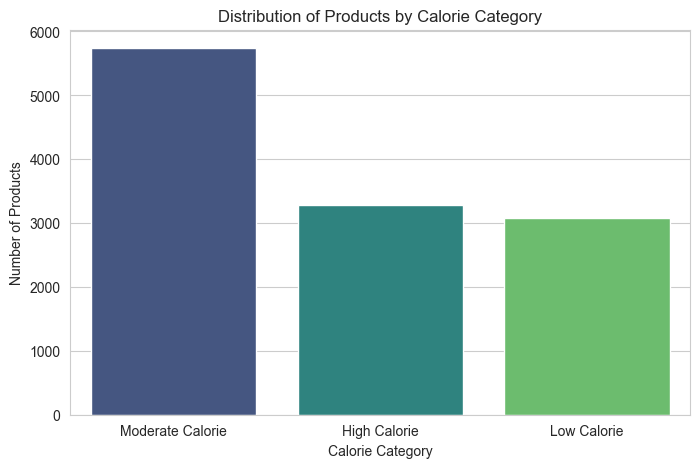

C:\Users\hp\AppData\Local\Temp\ipykernel_2068\3297740595.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


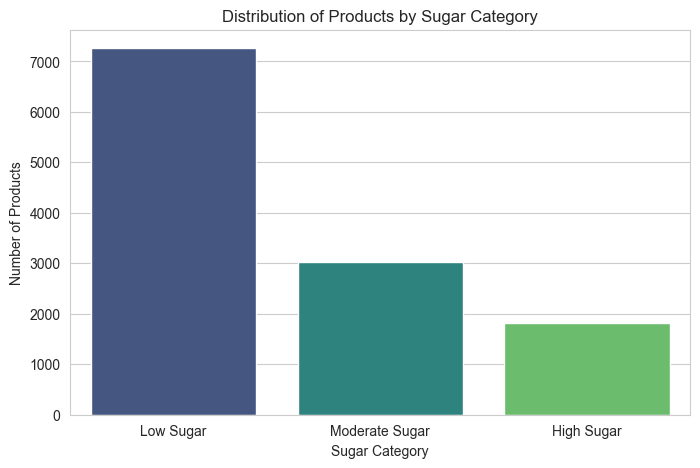

In [20]:
# Install libraries (works in Jupyter/Colab)
%pip install matplotlib seaborn

# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create a bar chart for Calorie Categories
plt.figure(figsize=(8, 5))
sns.countplot(
    data=merged_df_cleaned,
    x='calorie_category',
    order=merged_df_cleaned['calorie_category'].value_counts().index,
    palette='viridis'
)
plt.title('Distribution of Products by Calorie Category')
plt.xlabel('Calorie Category')
plt.ylabel('Number of Products')
plt.show()

# Create a bar chart for Sugar Categories
plt.figure(figsize=(8, 5))
sns.countplot(
    data=merged_df_cleaned,
    x='sugar_category',
    order=merged_df_cleaned['sugar_category'].value_counts().index,
    palette='viridis'
)
plt.title('Distribution of Products by Sugar Category')
plt.xlabel('Sugar Category')
plt.ylabel('Number of Products')
plt.show()


Note: you may need to restart the kernel to use updated packages.


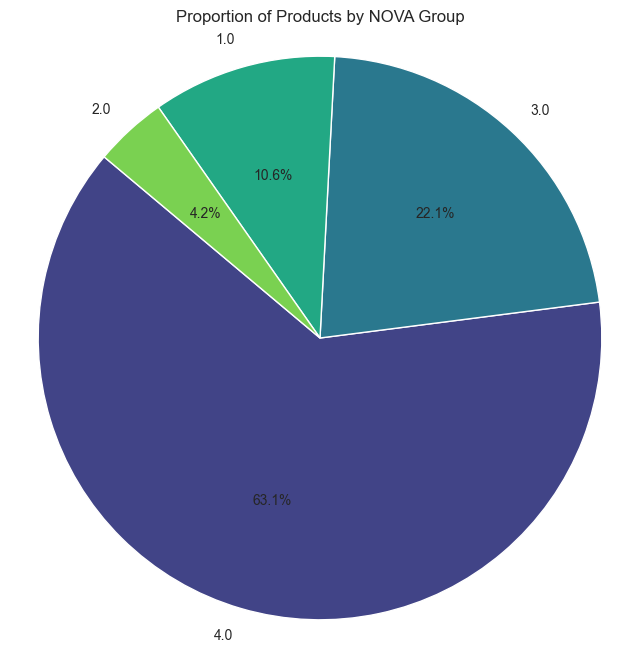

In [21]:
#Pie charts
# Install libraries (works in Jupyter/Colab)
%pip install matplotlib seaborn

# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pie chart for NOVA Groups
nova_group_counts = merged_df_cleaned['nova-group'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(nova_group_counts, labels=nova_group_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(nova_group_counts)))
plt.title('Proportion of Products by NOVA Group')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Note: you may need to restart the kernel to use updated packages.


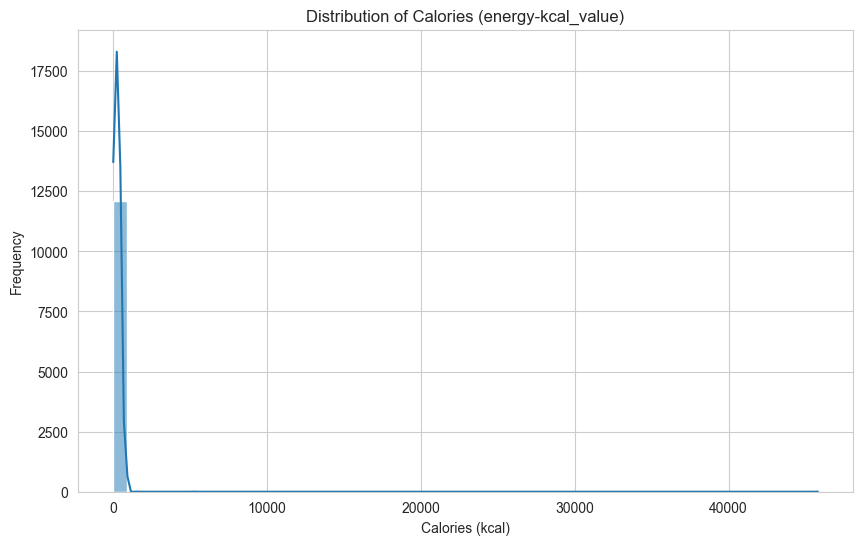

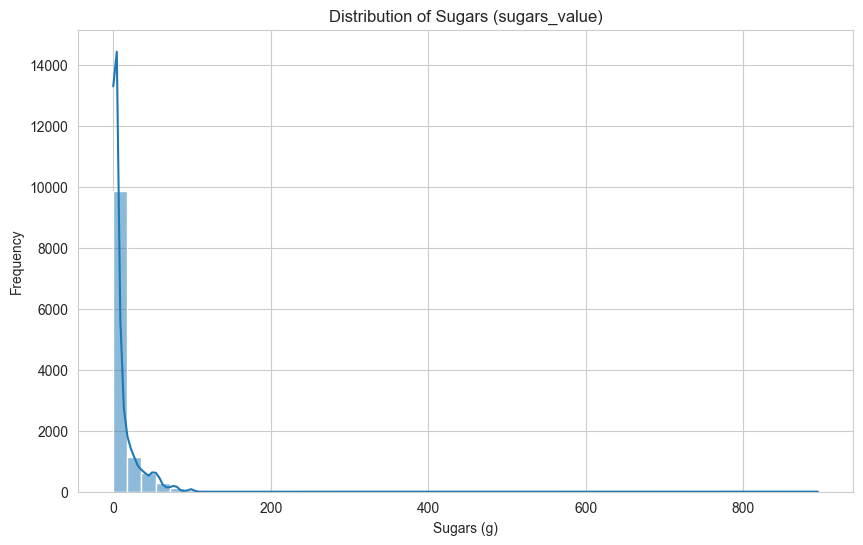

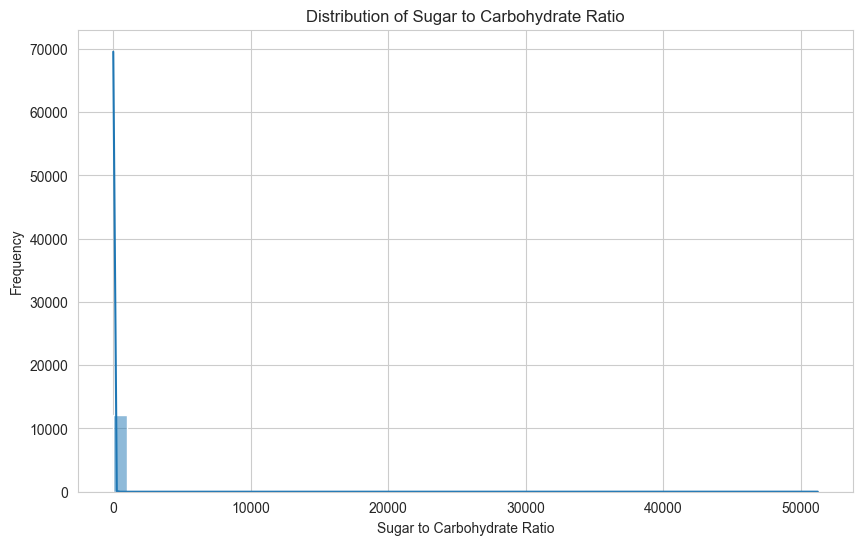

In [22]:
#Histograms
# Install libraries (works in Jupyter/Colab)
%pip install matplotlib seaborn

# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create a histogram for energy-kcal_value (Calories)
plt.figure(figsize=(10, 6))
sns.histplot(data=merged_df_cleaned, x='energy-kcal_value', kde=True, bins=50)
plt.title('Distribution of Calories (energy-kcal_value)')
plt.xlabel('Calories (kcal)')
plt.ylabel('Frequency')
plt.show()

# Create a histogram for sugars_value
plt.figure(figsize=(10, 6))
sns.histplot(data=merged_df_cleaned, x='sugars_value', kde=True, bins=50)
plt.title('Distribution of Sugars (sugars_value)')
plt.xlabel('Sugars (g)')
plt.ylabel('Frequency')
plt.show()

# Create a histogram for sugar_to_carb_ratio
plt.figure(figsize=(10, 6))
sns.histplot(data=merged_df_cleaned, x='sugar_to_carb_ratio', kde=True, bins=50)
plt.title('Distribution of Sugar to Carbohydrate Ratio')
plt.xlabel('Sugar to Carbohydrate Ratio')
plt.ylabel('Frequency')
plt.show()

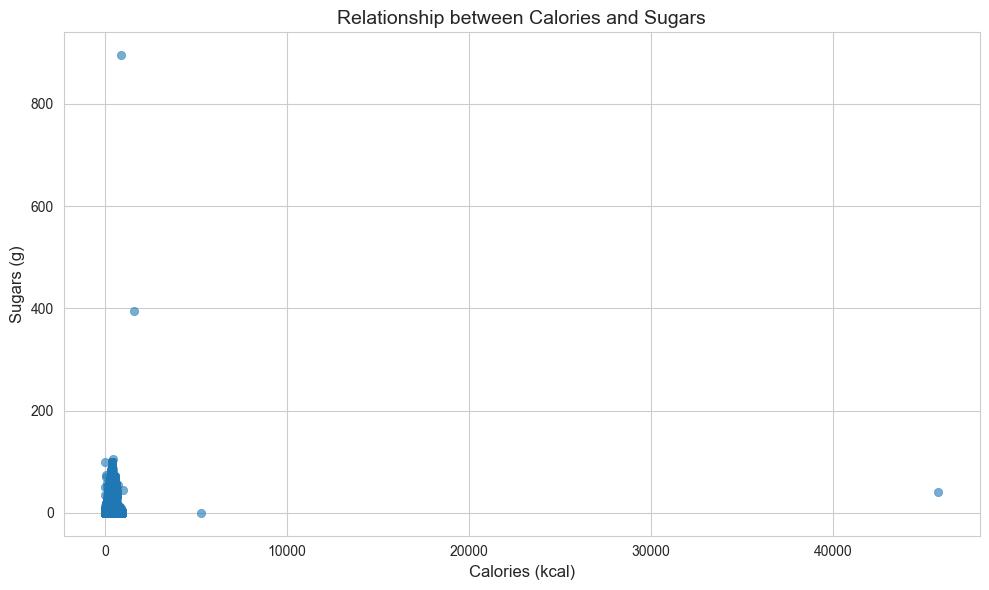

In [23]:
#scatter plot
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# ---------------- Scatter plot: Calories vs Sugars ----------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=merged_df_cleaned,
    x='energy-kcal_value',
    y='sugars_value',
    alpha=0.6,
    edgecolor=None  # avoids warnings about edgecolors
)
plt.title('Relationship between Calories and Sugars', fontsize=14)
plt.xlabel('Calories (kcal)', fontsize=12)
plt.ylabel('Sugars (g)', fontsize=12)
plt.tight_layout()
plt.show()


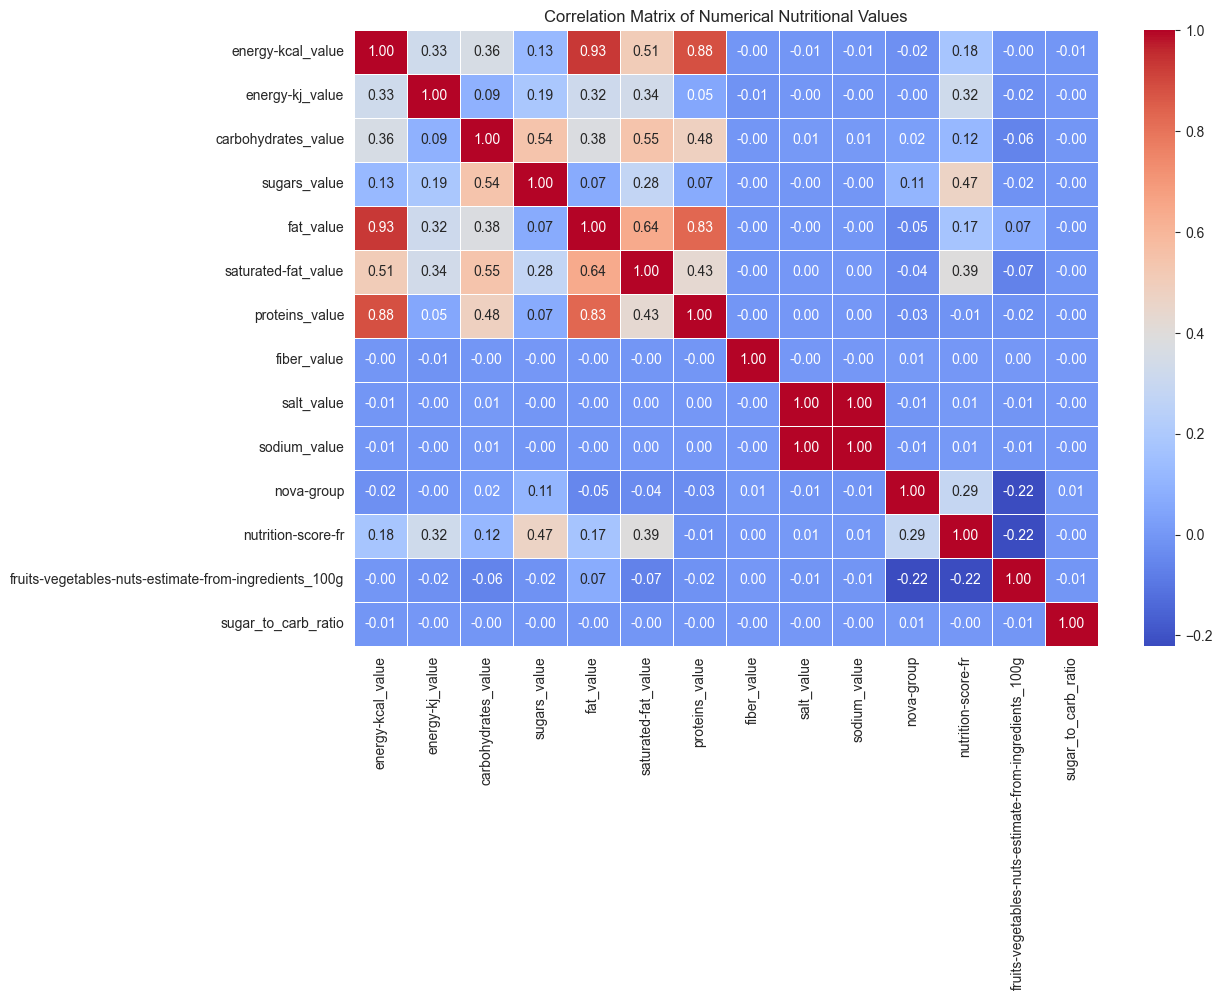

In [24]:
# Heatmaps in VS Code
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for the plots
sns.set_style("whitegrid")

# Select only numerical columns for correlation analysis
numerical_cols = merged_df_cleaned.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = merged_df_cleaned[numerical_cols].corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Nutritional Values')

# Show the plot (important in VS Code)
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_2068\3763646837.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_calories_brands, x='brands', y='energy-kcal_value', palette='viridis')


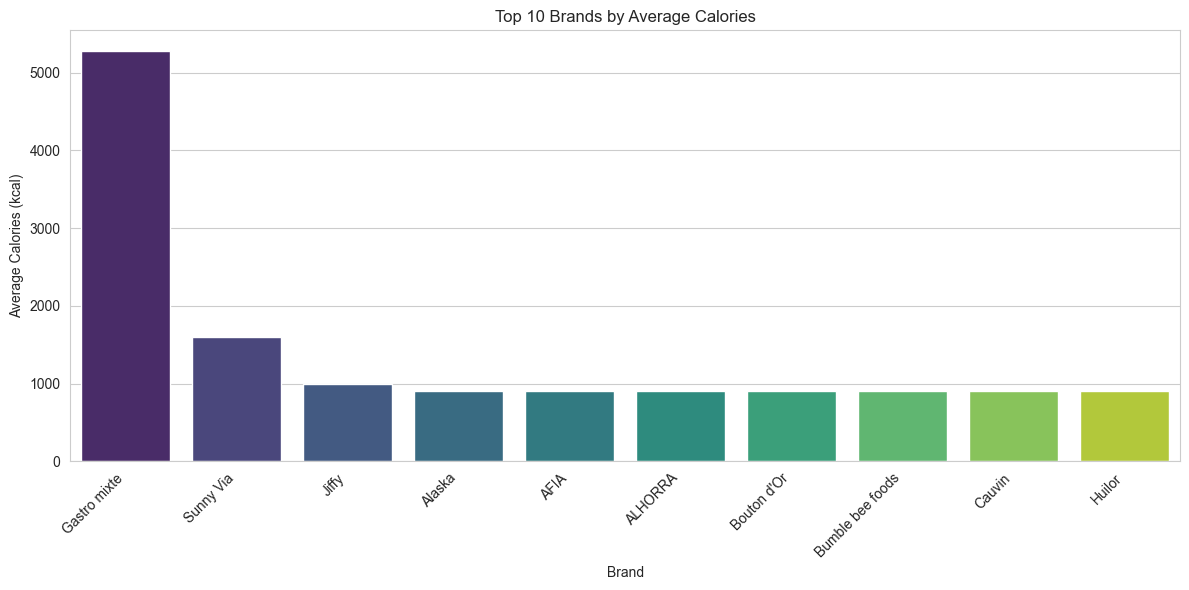

C:\Users\hp\AppData\Local\Temp\ipykernel_2068\3763646837.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sugars_brands, x='brands', y='sugars_value', palette='viridis')


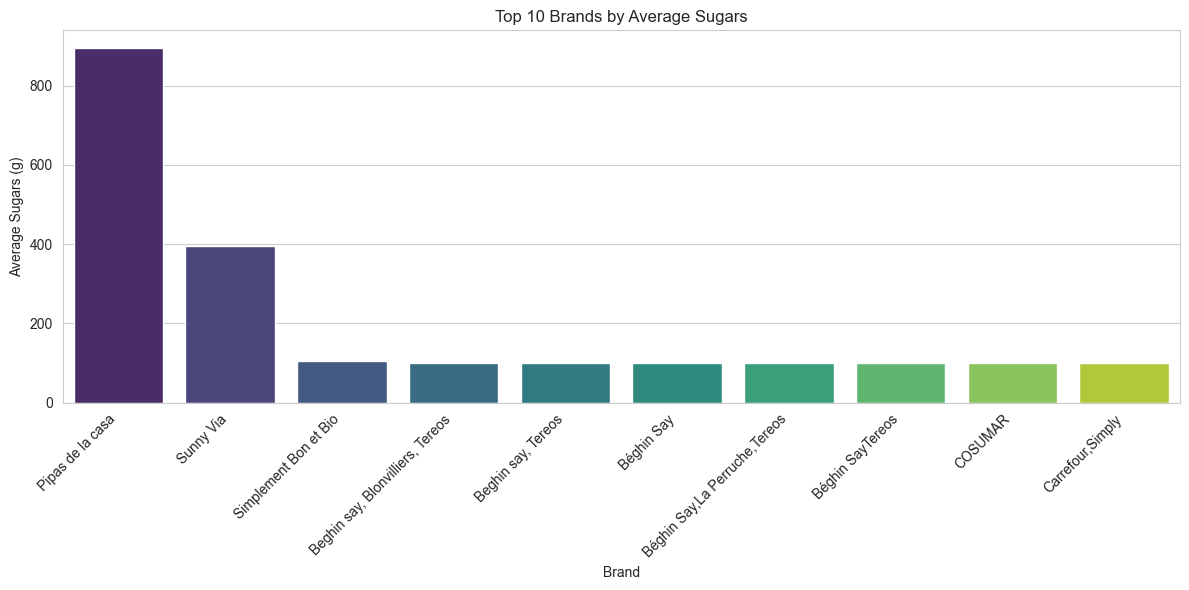

In [25]:
# %%  Top N bar plots
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Calculate average calories and sugars per brand
brand_avg_nutrients = merged_df_cleaned.groupby('brands')[['energy-kcal_value', 'sugars_value']].mean().reset_index()

# --- Top N brands by average calories ---
top_calories_brands = brand_avg_nutrients.nlargest(10, 'energy-kcal_value')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_calories_brands, x='brands', y='energy-kcal_value', palette='viridis')
plt.title('Top 10 Brands by Average Calories')
plt.xlabel('Brand')
plt.ylabel('Average Calories (kcal)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Top N brands by average sugars ---
top_sugars_brands = brand_avg_nutrients.nlargest(10, 'sugars_value')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_sugars_brands, x='brands', y='sugars_value', palette='viridis')
plt.title('Top 10 Brands by Average Sugars')
plt.xlabel('Brand')
plt.ylabel('Average Sugars (g)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [26]:
%pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [27]:
print("Columns in merged_df_cleaned:")
print(merged_df_cleaned.columns.tolist())


Columns in merged_df_cleaned:
['code', 'product_name', 'brands', 'energy-kcal_value', 'energy-kj_value', 'carbohydrates_value', 'sugars_value', 'fat_value', 'saturated-fat_value', 'proteins_value', 'fiber_value', 'salt_value', 'sodium_value', 'nova-group', 'nutrition-score-fr', 'fruits-vegetables-nuts-estimate-from-ingredients_100g', 'sugar_to_carb_ratio', 'calorie_category', 'sugar_category', 'is_ultra_processed']


In [30]:
print(merged_df_cleaned.columns)

Index(['code', 'product_name', 'brands', 'energy-kcal_value',
       'energy-kj_value', 'carbohydrates_value', 'sugars_value', 'fat_value',
       'saturated-fat_value', 'proteins_value', 'fiber_value', 'salt_value',
       'sodium_value', 'nova-group', 'nutrition-score-fr',
       'fruits-vegetables-nuts-estimate-from-ingredients_100g',
       'sugar_to_carb_ratio', 'calorie_category', 'sugar_category',
       'is_ultra_processed'],
      dtype='object')


In [29]:
import mysql.connector
import pandas as pd

# Step 0: Load your cleaned DataFrame
# Example:
# merged_df_cleaned = pd.read_csv("cleaned_dataset.csv")

# Step 1: Connect to MySQL (no DB first)
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=""   # XAMPP default
)
cursor = conn.cursor()

# Step 2: Create database if not exists
cursor.execute("CREATE DATABASE IF NOT EXISTS food_db")
print("✅ Database 'food_db' ready!")

# Step 3: Reconnect with database
conn.close()
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="food_db"
)
cursor = conn.cursor()

# Step 4: Create tables with PRIMARY KEYS
cursor.execute("""
CREATE TABLE IF NOT EXISTS product_info (
    product_code VARCHAR(50) PRIMARY KEY,
    product_name TEXT,
    brand TEXT
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS nutrient_info (
    product_code VARCHAR(50) PRIMARY KEY,
    energy_kcal_value FLOAT,
    energy_kj_value FLOAT,
    carbohydrates_value FLOAT,
    sugars_value FLOAT,
    fat_value FLOAT,
    saturated_fat_value FLOAT,
    proteins_value FLOAT,
    fiber_value FLOAT,
    salt_value FLOAT,
    sodium_value FLOAT,
    fruits_vegetables_nuts_estimate_from_ingredients_100g FLOAT,
    nutrition_score_fr INT,
    nova_group INT,
    FOREIGN KEY (product_code) REFERENCES product_info(product_code)
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS derived_metrics (
    product_code VARCHAR(50) PRIMARY KEY,
    sugar_to_carb_ratio FLOAT,
    calorie_category TEXT,
    sugar_category TEXT,
    is_ultra_processed TEXT,
    FOREIGN KEY (product_code) REFERENCES product_info(product_code)
)
""")
print("✅ Tables created successfully!")

# --------------------------------------------------
# Step 5: Prepare DataFrames with correct column mapping
# --------------------------------------------------
df_product_info = merged_df_cleaned[['code', 'product_name', 'brands']].drop_duplicates()

df_nutrient_info = merged_df_cleaned[[
    'code',
    'energy-kcal_value',      # original col in CSV
    'energy-kj_value',
    'carbohydrates_value',
    'sugars_value',
    'fat_value',
    'saturated-fat_value',
    'proteins_value',
    'fiber_value',
    'salt_value',
    'sodium_value',
    'fruits-vegetables-nuts-estimate-from-ingredients_100g',
    'nutrition-score-fr',
    'nova-group'
]].rename(columns={   # rename to match MySQL table
    'energy-kcal_value': 'energy_kcal_value',
    'energy-kj_value': 'energy_kj_value',
    'saturated-fat_value': 'saturated_fat_value',
    'fruits-vegetables-nuts-estimate-from-ingredients_100g': 'fruits_vegetables_nuts_estimate_from_ingredients_100g',
    'nutrition-score-fr': 'nutrition_score_fr',
    'nova-group': 'nova_group'
})

df_derived_metrics = merged_df_cleaned[[
    'code',
    'sugar_to_carb_ratio',
    'calorie_category',
    'sugar_category',
    'is_ultra_processed'
]]

# --------------------------------------------------
# Step 6: Insert into product_info
# --------------------------------------------------
for _, row in df_product_info.iterrows():
    cursor.execute("""
        INSERT IGNORE INTO product_info (product_code, product_name, brand)
        VALUES (%s, %s, %s)
    """, (row['code'], row['product_name'], row['brands']))

# --------------------------------------------------
# Step 7: Insert into nutrient_info
# --------------------------------------------------
for _, row in df_nutrient_info.iterrows():
    cursor.execute("""
        INSERT IGNORE INTO nutrient_info (
            product_code, energy_kcal_value, energy_kj_value, carbohydrates_value, sugars_value,
            fat_value, saturated_fat_value, proteins_value, fiber_value, salt_value,
            sodium_value, fruits_vegetables_nuts_estimate_from_ingredients_100g,
            nutrition_score_fr, nova_group
        ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
    """, (
        row['code'], row['energy_kcal_value'], row['energy_kj_value'],
        row['carbohydrates_value'], row['sugars_value'], row['fat_value'],
        row['saturated_fat_value'], row['proteins_value'], row['fiber_value'],
        row['salt_value'], row['sodium_value'],
        row['fruits_vegetables_nuts_estimate_from_ingredients_100g'],
        row['nutrition_score_fr'], row['nova_group']
    ))

# --------------------------------------------------
# Step 8: Insert into derived_metrics
# --------------------------------------------------
for _, row in df_derived_metrics.iterrows():
    cursor.execute("""
        INSERT IGNORE INTO derived_metrics (
            product_code, sugar_to_carb_ratio, calorie_category, sugar_category, is_ultra_processed
        ) VALUES (%s, %s, %s, %s, %s)
    """, (row['code'], row['sugar_to_carb_ratio'], row['calorie_category'],
          row['sugar_category'], row['is_ultra_processed']))

# --------------------------------------------------
# Step 9: Commit & Close
# --------------------------------------------------
conn.commit()
print("✅ Data inserted successfully! No duplicates created.")



✅ Database 'food_db' ready!
✅ Tables created successfully!
✅ Data inserted successfully! No duplicates created.


In [30]:

# Step 1: Connect to MySQL (no DB first)
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=""   # XAMPP default
)
cursor = conn.cursor()

In [31]:
import mysql.connector
import pandas as pd

# --------------------------------------------------
# Step 1: Connect to MySQL database
# --------------------------------------------------
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="food_db"
)
cursor = conn.cursor()

# Helper function to run query and display as DataFrame
def run_query(query, description):
    print(f"\n▶ {description}")
    cursor.execute(query)
    rows = cursor.fetchall()
    cols = [i[0] for i in cursor.description]
    df = pd.DataFrame(rows, columns=cols)
    print(df)
    return df


# --------------------------------------------------
# 📑 product_info Queries
# --------------------------------------------------
run_query("""
    SELECT brand, COUNT(*) AS product_count
    FROM product_info
    GROUP BY brand
""", "Count products per brand")

run_query("""
    SELECT brand, COUNT(DISTINCT product_code) AS unique_products
    FROM product_info
    GROUP BY brand
""", "Count unique products per brand")

run_query("""
    SELECT brand, COUNT(*) AS product_count
    FROM product_info
    GROUP BY brand
    ORDER BY product_count DESC
    LIMIT 5
""", "Top 5 brands by product count")

run_query("""
    SELECT product_code, brand
    FROM product_info
    WHERE product_name IS NULL OR product_name = ''
""", "Products with missing product name")

run_query("""
    SELECT COUNT(DISTINCT brand) AS unique_brands
    FROM product_info
""", "Number of unique brands")

run_query("""
    SELECT *
    FROM product_info
    WHERE product_code LIKE '3%'
""", "Products with code starting with '3'")


# --------------------------------------------------
# 📑 nutrient_info Queries
# --------------------------------------------------
run_query("""
    SELECT product_code, energy_kcal_value
    FROM nutrient_info
    ORDER BY energy_kcal_value DESC
    LIMIT 10
""", "Top 10 products with highest energy-kcal_value")

run_query("""
    SELECT nova_group, AVG(sugars_value) AS avg_sugars
    FROM nutrient_info
    GROUP BY nova_group
""", "Average sugars_value per nova-group")

run_query("""
    SELECT COUNT(*) AS high_fat_products
    FROM nutrient_info
    WHERE fat_value > 20
""", "Count products with fat_value > 20g")

run_query("""
    SELECT product_code, AVG(carbohydrates_value) AS avg_carbs
    FROM nutrient_info
    GROUP BY product_code
""", "Average carbohydrates_value per product")

run_query("""
    SELECT product_code, sodium_value
    FROM nutrient_info
    WHERE sodium_value > 1
""", "Products with sodium_value > 1g")

run_query("""
    SELECT COUNT(*) AS nonzero_fvn_products
    FROM nutrient_info
    WHERE fruits_vegetables_nuts_estimate_from_ingredients_100g > 0
""", "Count products with non-zero fruits-vegetables-nuts content")

run_query("""
    SELECT product_code, energy_kcal_value
    FROM nutrient_info
    WHERE energy_kcal_value > 500
""", "Products with energy-kcal_value > 500")


# --------------------------------------------------
# 📑 derived_metrics Queries
# --------------------------------------------------
run_query("""
    SELECT calorie_category, COUNT(*) AS product_count
    FROM derived_metrics
    GROUP BY calorie_category
""", "Count products per calorie_category")

run_query("""
    SELECT COUNT(*) AS high_sugar_products
    FROM derived_metrics
    WHERE sugar_category = 'High Sugar'
""", "Count of High Sugar products")

run_query("""
    SELECT AVG(sugar_to_carb_ratio) AS avg_ratio
    FROM derived_metrics
    WHERE calorie_category = 'High Calorie'
""", "Average sugar_to_carb_ratio for High Calorie products")

run_query("""
    SELECT product_code
    FROM derived_metrics
    WHERE calorie_category = 'High Calorie'
      AND sugar_category = 'High Sugar'
""", "Products that are both High Calorie and High Sugar")

run_query("""
    SELECT COUNT(*) AS ultra_processed_count
    FROM derived_metrics
    WHERE is_ultra_processed = 'Yes'
""", "Number of products marked as ultra-processed")

run_query("""
    SELECT product_code, sugar_to_carb_ratio
    FROM derived_metrics
    WHERE sugar_to_carb_ratio > 0.7
""", "Products with sugar_to_carb_ratio > 0.7")

run_query("""
    SELECT calorie_category, AVG(sugar_to_carb_ratio) AS avg_ratio
    FROM derived_metrics
    GROUP BY calorie_category
""", "Average sugar_to_carb_ratio per calorie_category")


# --------------------------------------------------
# Step 2: Close connection
# --------------------------------------------------
conn.commit()   # not really needed for SELECT, but safe
cursor.close()
conn.close()



▶ Count products per brand
                                                  brand  product_count
0                                                                  109
1     07 x Aldi 09.25, 09 x Aldi 09.25, 11 x Aldi 09...              1
2     1001 Delights (Lidl), Envia, Lidl, Milbona, Mi...              1
3     1540 Vestby, Norwegen, Oluf Lorentzen AS, Tove...              1
4     166, 43122 Parma - Italy, Barilla, Barilla - B...              1
...                                                 ...            ...
3417                                               كنور              1
3418                                            كوسومار              1
3419                                            لاسيگون              1
3420                                               نلزه              1
3421                         ولماس ماء معدني غازي طبيعي              1

[3422 rows x 2 columns]

▶ Count unique products per brand
                                                  brand  uni

In [ ]:
-- Count products per brand
SELECT brand, COUNT(*) AS product_count
FROM product_info
GROUP BY brand;

-- Count unique products per brand
SELECT brand, COUNT(DISTINCT product_code) AS unique_products
FROM product_info
GROUP BY brand;

-- Top 5 brands by product count
SELECT brand, COUNT(*) AS product_count
FROM product_info
GROUP BY brand
ORDER BY product_count DESC
LIMIT 5;

-- Products with missing product name
SELECT product_code, brand
FROM product_info
WHERE product_name IS NULL OR product_name = '';

-- Number of unique brands
SELECT COUNT(DISTINCT brand) AS unique_brands
FROM product_info;

-- Products with code starting with '3'
SELECT *
FROM product_info
WHERE product_code LIKE '3%';


In [ ]:
-- Top 10 products with highest energy-kcal_value
SELECT product_code, energy_kcal_value
FROM nutrient_info
ORDER BY energy_kcal_value DESC
LIMIT 10;

-- Average sugars_value per nova-group
SELECT nova_group, AVG(sugars_value) AS avg_sugars
FROM nutrient_info
GROUP BY nova_group;

-- Count products with fat_value > 20g
SELECT COUNT(*) AS high_fat_products
FROM nutrient_info
WHERE fat_value > 20;

-- Average carbohydrates_value per product
SELECT product_code, AVG(carbohydrates_value) AS avg_carbs
FROM nutrient_info
GROUP BY product_code;

-- Products with sodium_value > 1g
SELECT product_code, sodium_value
FROM nutrient_info
WHERE sodium_value > 1;

-- Count products with non-zero fruits-vegetables-nuts content
SELECT COUNT(*) AS nonzero_fvn_products
FROM nutrient_info
WHERE fruits_vegetables_nuts_estimate_from_ingredients_100g > 0;

-- Products with energy-kcal_value > 500
SELECT product_code, energy_kcal_value
FROM nutrient_info
WHERE energy_kcal_value > 500;


In [ ]:
-- Count products per calorie_category
SELECT calorie_category, COUNT(*) AS product_count
FROM derived_metrics
GROUP BY calorie_category;

-- Count of High Sugar products
SELECT COUNT(*) AS high_sugar_products
FROM derived_metrics
WHERE sugar_category = 'High Sugar';

-- Average sugar_to_carb_ratio for High Calorie products
SELECT AVG(sugar_to_carb_ratio) AS avg_ratio
FROM derived_metrics
WHERE calorie_category = 'High Calorie';

-- Products that are both High Calorie and High Sugar
SELECT product_code
FROM derived_metrics
WHERE calorie_category = 'High Calorie'
  AND sugar_category = 'High Sugar';

-- Number of products marked as ultra-processed
SELECT COUNT(*) AS ultra_processed_count
FROM derived_metrics
WHERE is_ultra_processed = 'Yes';

-- Products with sugar_to_carb_ratio > 0.7
SELECT product_code, sugar_to_carb_ratio
FROM derived_metrics
WHERE sugar_to_carb_ratio > 0.7;

-- Average sugar_to_carb_ratio per calorie_category
SELECT calorie_category, AVG(sugar_to_carb_ratio) AS avg_ratio
FROM derived_metrics
GROUP BY calorie_category;
